# Understanding BOCPD Outputs

This tutorial provides a deep dive into the statistical outputs of BOCPD and how to interpret them.

## What You'll Learn

- The posterior distribution over run lengths: $P(r_t = r \mid x_{1:t})$
- Changepoint probability: $P(r_t = 0 \mid x_{1:t})$
- Maximum A Posteriori (MAP) run length estimation
- Confidence quantification
- Visualizing uncertainty

## Prerequisites

Complete tutorials 01 (Quickstart) and 02 (Online vs Batch) first.

---

## Setup

Import libraries and prepare visualization utilities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from fast_bocpd import BOCPD, GaussianNIG, ConstantHazard

print("Libraries loaded successfully")

Libraries loaded successfully


---
## 1. The Run Length Posterior Distribution

BOCPD is a **probabilistic** algorithm. At each time $t$, it maintains a full probability distribution over run lengths:

$$P(r_t = r \mid x_{1:t}) \quad \text{for } r = 0, 1, \ldots, R_{max}$$

### What is Run Length?

The run length $r_t$ is the number of observations since the most recent changepoint:
- $r_t = 0$: A changepoint just occurred at time $t$
- $r_t = 5$: The last changepoint was 5 steps ago
- $r_t = 100$: We've been in the same segment for 100 observations

### What is the Posterior?

The posterior $P(r_t = r \mid x_{1:t})$ represents our **belief** about the run length after observing data up to time $t$.

**Key insight:** This is a distribution over a discrete variable, so:
$$\sum_{r=0}^{R_{max}} P(r_t = r \mid x_{1:t}) = 1$$

Let's visualize this distribution and understand what it tells us.

---
## 2. Observing the Posterior Evolution

Generate data with a single changepoint and watch how the posterior evolves.

In [2]:
# Generate data: changepoint at t=30
np.random.seed(42)
data = np.concatenate([
    np.random.randn(30) * 0.5 + 0.0,
    np.random.randn(30) * 0.5 + 5.0
])

# Configure BOCPD
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)
bocpd = BOCPD(model, hazard, max_run_length=50)

# Store posteriors at each time step
posteriors = []
cp_probs = []

for x in data:
    posterior_r, cp_prob = bocpd.update(x)
    posteriors.append(posterior_r.copy())
    cp_probs.append(cp_prob)

posteriors = np.array(posteriors)
cp_probs = np.array(cp_probs)

print(f"Collected {len(posteriors)} posterior distributions")
print(f"Each posterior has {posteriors.shape[1]} elements (r = 0 to {posteriors.shape[1]-1})")

Collected 60 posterior distributions
Each posterior has 51 elements (r = 0 to 50)


---
## 3. Visualizing the Posterior as a Heatmap

The **run length posterior matrix** is a powerful visualization tool.

Each row represents time $t$, each column represents run length $r$, and the color intensity shows $P(r_t = r \mid x_{1:t})$.

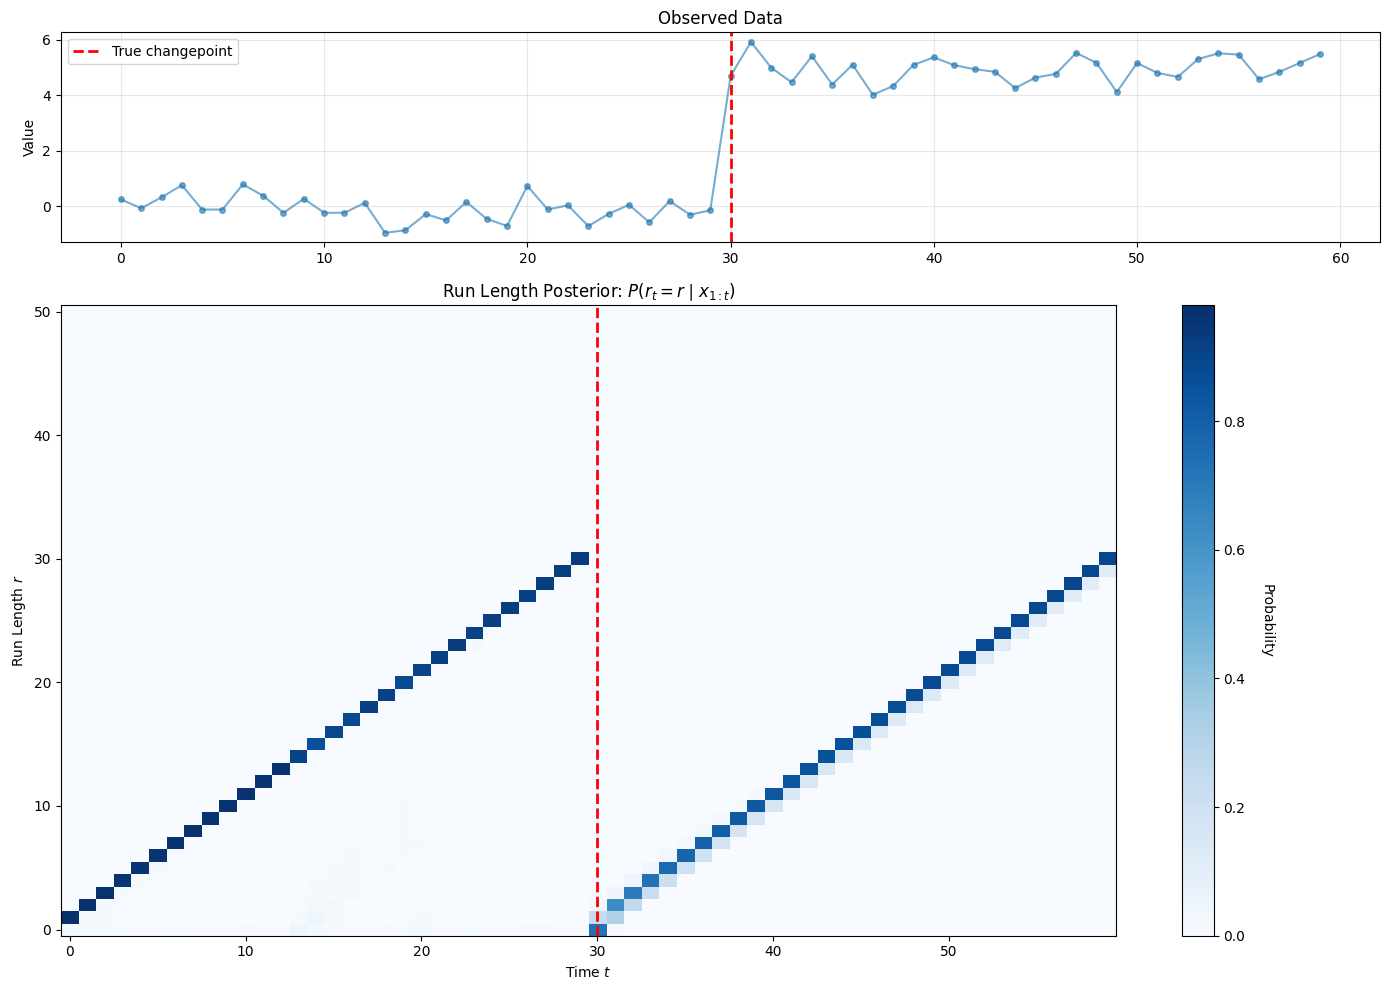


Interpretation:
- Bright diagonal lines: High probability that run length increases by 1 each step
- Vertical bright band at t=30: Posterior concentrates at r=0 (changepoint detected)
- New diagonal after t=30: Algorithm restarts, tracking new segment


In [3]:
# Create run length posterior heatmap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                gridspec_kw={'height_ratios': [1, 3]})

# Top: Data
ax1.plot(data, 'o-', alpha=0.6, markersize=4)
ax1.axvline(30, color='red', linestyle='--', linewidth=2, label='True changepoint')
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: Posterior heatmap
im = ax2.imshow(posteriors.T, aspect='auto', origin='lower', 
                cmap='Blues', interpolation='nearest')
ax2.axvline(30, color='red', linestyle='--', linewidth=2, label='True changepoint')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel('Run Length $r$')
ax2.set_title('Run Length Posterior: $P(r_t = r\\mid x_{1:t})$')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Probability', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Bright diagonal lines: High probability that run length increases by 1 each step")
print("- Vertical bright band at t=30: Posterior concentrates at r=0 (changepoint detected)")
print("- New diagonal after t=30: Algorithm restarts, tracking new segment")

---
## 4. Understanding Changepoint Probability

The **changepoint probability** is simply the posterior at $r = 0$:

$$P(\text{changepoint at } t) = P(r_t = 0 \mid x_{1:t})$$

This is the first element of the posterior distribution.

### Why $r_t = 0$ means changepoint?

By definition, $r_t = 0$ means "zero observations since the last changepoint", which is equivalent to "a changepoint just occurred at time $t$".

Let's extract and visualize this.

CP probs match: True
Maximum difference: 0.00e+00


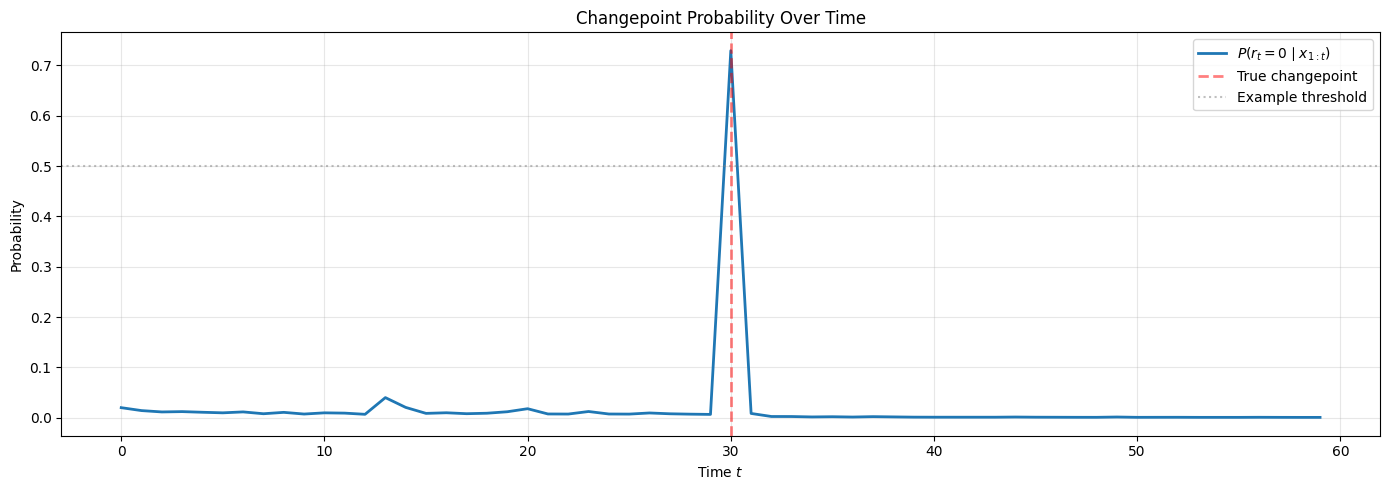


Peak CP probability: 0.729 at t=30


In [4]:
# Extract changepoint probabilities (r=0 column)
cp_probs_from_posterior = posteriors[:, 0]

# Verify they match what bocpd.update() returned
print(f"CP probs match: {np.allclose(cp_probs, cp_probs_from_posterior)}")
print(f"Maximum difference: {np.max(np.abs(cp_probs - cp_probs_from_posterior)):.2e}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cp_probs, linewidth=2, label='$P(r_t = 0 \\mid x_{1:t})$')
ax.axvline(30, color='red', linestyle='--', alpha=0.5, linewidth=2, label='True changepoint')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Example threshold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Probability')
ax.set_title('Changepoint Probability Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPeak CP probability: {cp_probs.max():.3f} at t={cp_probs.argmax()}")

---
## 5. Maximum A Posteriori (MAP) Estimation

While the full posterior provides complete information, we often want a **point estimate**. The MAP estimate is:

$$r_{MAP}(t) = \arg\max_r P(r_t = r \mid x_{1:t})$$

This is the **most probable** run length given the observed data.

### Why MAP?

- **Interpretability:** Single number instead of a distribution
- **Decision-making:** "What is our best guess for the run length?"
- **Changepoint detection:** When $r_{MAP} = 0$, a changepoint is the most likely explanation

### MAP vs Mean vs Median

Different point estimates serve different purposes:
- **MAP:** Most probable value (mode of distribution)
- **Mean:** Expected value $\mathbb{E}[r_t \mid x_{1:t}]$
- **Median:** 50th percentile

For changepoint detection, MAP is preferred because it directly indicates when $r=0$ is most likely.

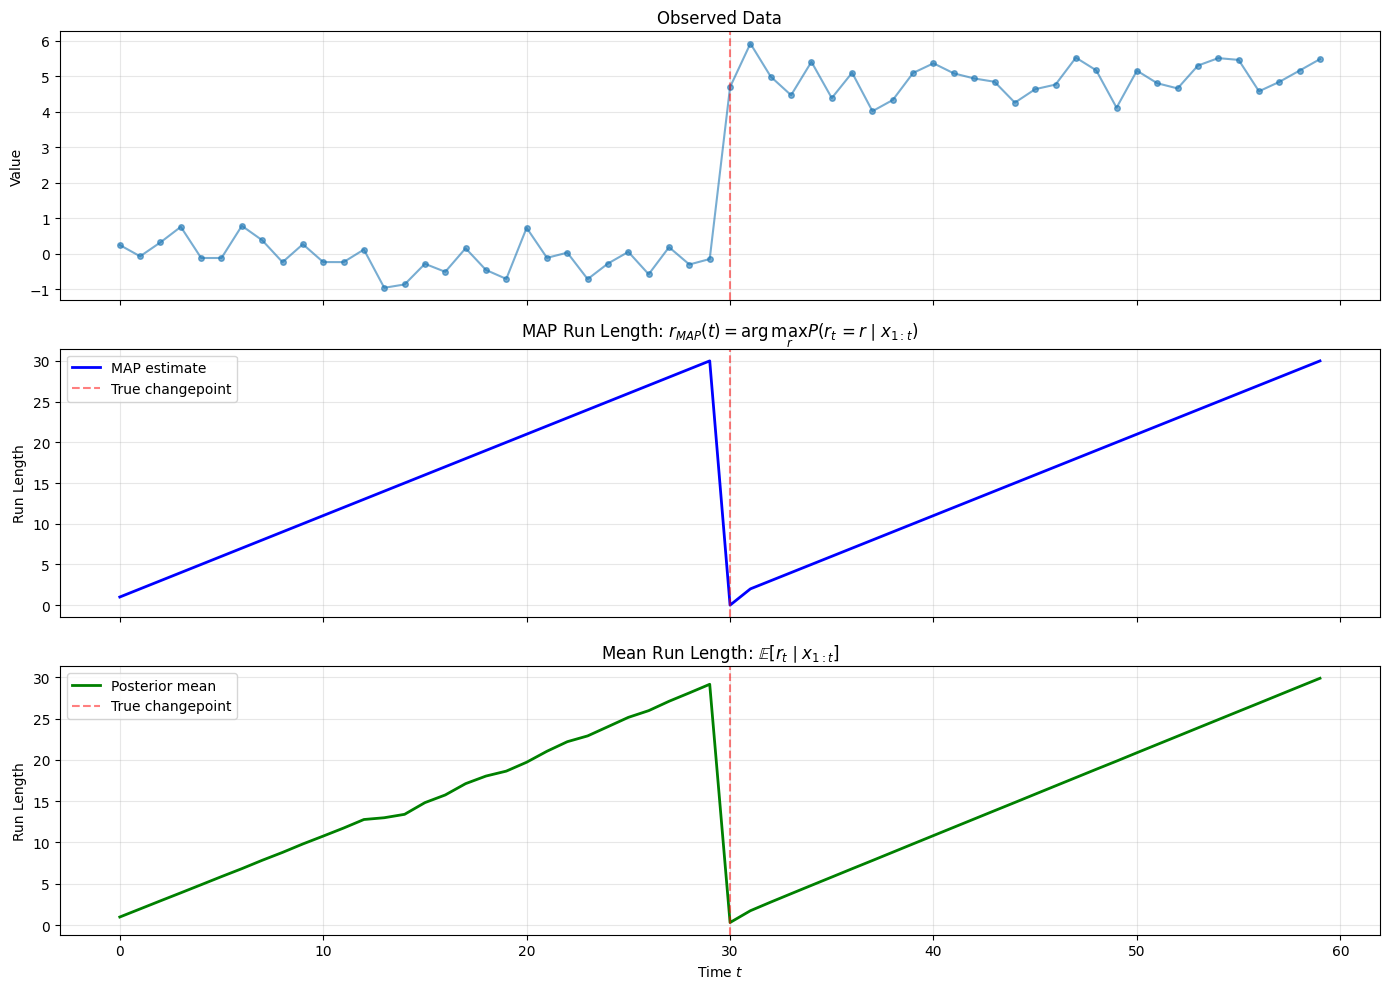

Notice how MAP jumps to 0 at changepoint, while mean is smoother


In [5]:
# Compute MAP at each time step
map_estimates = np.argmax(posteriors, axis=1)

# Also compute mean for comparison
mean_estimates = np.sum(posteriors * np.arange(posteriors.shape[1]), axis=1)

# Plot both
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Data
ax1.plot(data, 'o-', alpha=0.6, markersize=4)
ax1.axvline(30, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.grid(True, alpha=0.3)

# MAP estimate
ax2.plot(map_estimates, linewidth=2, color='blue', label='MAP estimate')
ax2.axvline(30, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax2.set_ylabel('Run Length')
ax2.set_title('MAP Run Length: $r_{MAP}(t) = \\arg\\max_r P(r_t = r \\mid x_{1:t})$')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mean estimate
ax3.plot(mean_estimates, linewidth=2, color='green', label='Posterior mean')
ax3.axvline(30, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax3.set_xlabel('Time $t$')
ax3.set_ylabel('Run Length')
ax3.set_title('Mean Run Length: $\\mathbb{E}[r_t \\mid x_{1:t}]$')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice how MAP jumps to 0 at changepoint, while mean is smoother")

---
## 6. Confidence in MAP Estimate

The MAP estimate is just the mode of the distribution. But how **confident** are we?

**Confidence** is the posterior probability at the MAP estimate:

$$\text{Confidence} = P(r_t = r_{MAP}(t) \mid x_{1:t})$$

### Interpretation:

- **High confidence (close to 1):** Posterior is concentrated, we're certain
- **Low confidence (closer to 0):** Posterior is diffuse, uncertainty is high

### Why Confidence Dips at Changepoints

**Important observation:** Confidence typically **decreases** right at changepoints. This is correct behavior!

**Before changepoint:** Data is consistent → posterior concentrates → high confidence  
**At changepoint:** Sudden shift → multiple hypotheses compete → **low confidence**  
**After changepoint:** New pattern establishes → posterior reconcentrates → high confidence

The dip reflects genuine **uncertainty** about exactly when the changepoint occurred and what the new regime is. This is a feature, not a bug - the algorithm correctly expresses doubt during transitions.

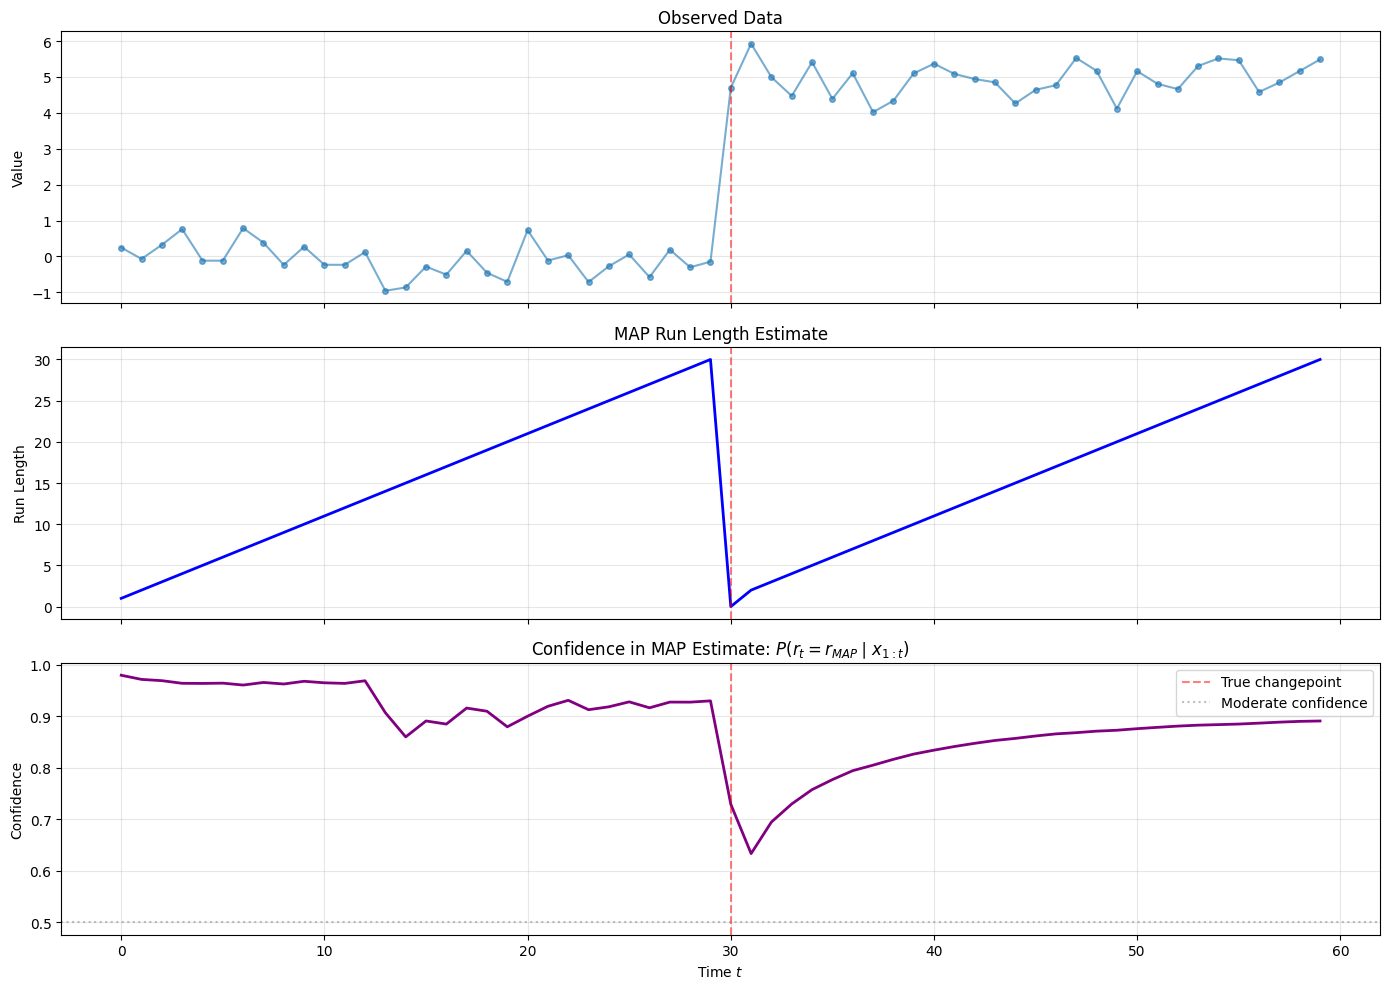

Average confidence: 0.884
Confidence range: [0.634, 0.980]

High confidence at changepoint: 0.729


In [6]:
# Compute confidence at each time step
confidence = posteriors[np.arange(len(posteriors)), map_estimates]

# Visualize
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Data
ax1.plot(data, 'o-', alpha=0.6, markersize=4)
ax1.axvline(30, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.grid(True, alpha=0.3)

# MAP estimate
ax2.plot(map_estimates, linewidth=2, color='blue')
ax2.axvline(30, color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Run Length')
ax2.set_title('MAP Run Length Estimate')
ax2.grid(True, alpha=0.3)

# Confidence
ax3.plot(confidence, linewidth=2, color='purple')
ax3.axvline(30, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax3.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Moderate confidence')
ax3.set_xlabel('Time $t$')
ax3.set_ylabel('Confidence')
ax3.set_title('Confidence in MAP Estimate: $P(r_t = r_{MAP} \\mid x_{1:t})$')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average confidence: {confidence.mean():.3f}")
print(f"Confidence range: [{confidence.min():.3f}, {confidence.max():.3f}]")
print(f"\nHigh confidence at changepoint: {confidence[30]:.3f}")

---
## 7. Uncertainty Quantification

The full posterior allows us to quantify uncertainty using **credible intervals**.

A **95% credible interval** contains run lengths that account for 95% of the posterior mass.

This goes beyond point estimates to capture our uncertainty about the run length.

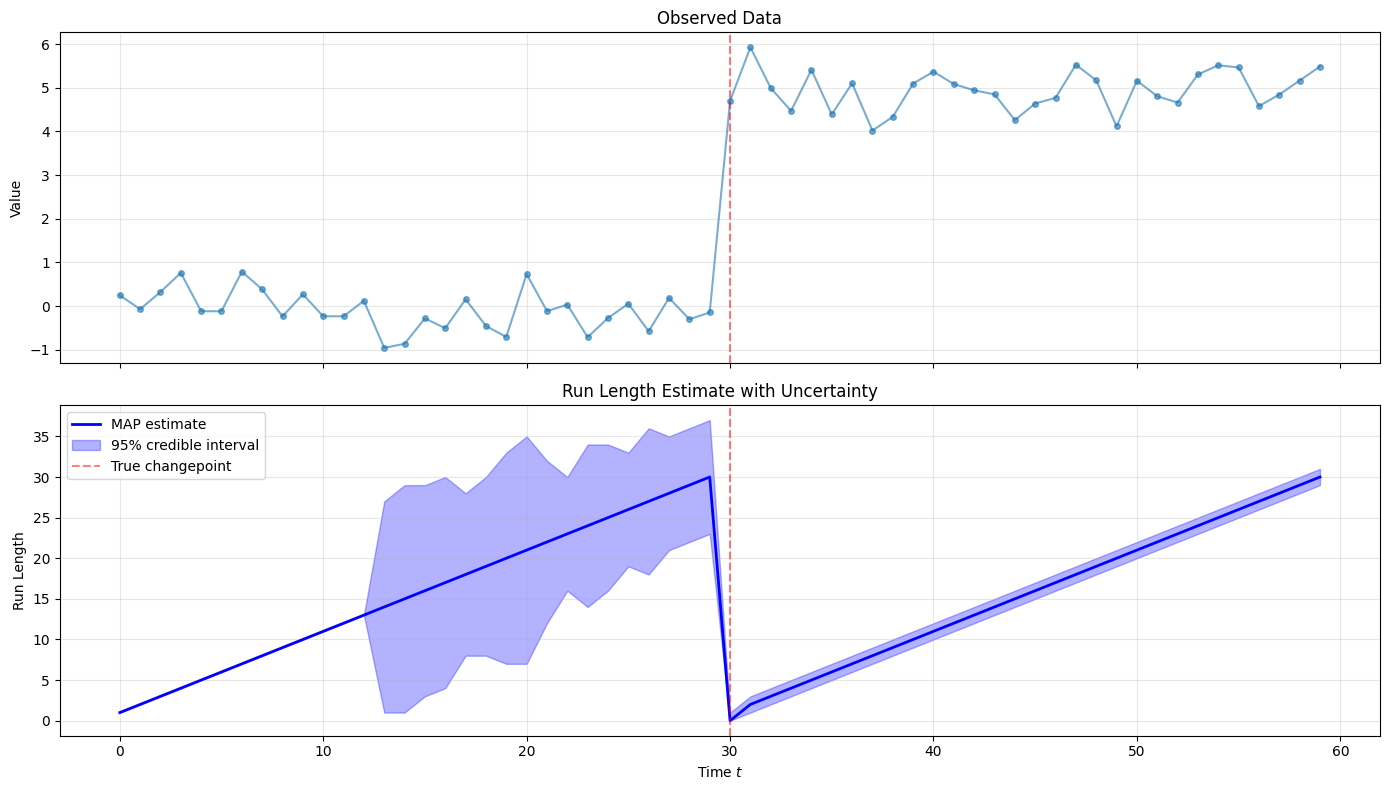

The shaded region shows where we're 95% confident the true run length lies


In [7]:
def compute_credible_interval(posterior, credibility=0.95):
    """
    Compute credible interval for run length.
    
    Returns (lower, upper) such that P(lower <= r <= upper) >= credibility
    """
    cumsum = np.cumsum(posterior)
    
    # Find interval centered around mode if possible
    mode_idx = np.argmax(posterior)
    
    # Expand from mode until we have enough mass
    lower = mode_idx
    upper = mode_idx
    
    while (cumsum[upper] - (cumsum[lower-1] if lower > 0 else 0)) < credibility:
        if upper < len(posterior) - 1:
            upper += 1
        if lower > 0 and (cumsum[upper] - cumsum[lower-1]) < credibility:
            lower -= 1
        if upper >= len(posterior) - 1 and lower == 0:
            break
    
    return lower, upper

# Compute 95% credible intervals
intervals = [compute_credible_interval(p, 0.95) for p in posteriors]
lower_bounds = np.array([i[0] for i in intervals])
upper_bounds = np.array([i[1] for i in intervals])

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Data
ax1.plot(data, 'o-', alpha=0.6, markersize=4)
ax1.axvline(30, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.grid(True, alpha=0.3)

# Run length with uncertainty
ax2.plot(map_estimates, linewidth=2, color='blue', label='MAP estimate')
ax2.fill_between(range(len(posteriors)), lower_bounds, upper_bounds, 
                  alpha=0.3, color='blue', label='95% credible interval')
ax2.axvline(30, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel('Run Length')
ax2.set_title('Run Length Estimate with Uncertainty')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The shaded region shows where we're 95% confident the true run length lies")

---
## 8. Entropy as Uncertainty Measure

**Entropy** quantifies the uncertainty in the posterior distribution:

$$H(r_t) = -\sum_{r=0}^{R_{max}} P(r_t = r \mid x_{1:t}) \log P(r_t = r \mid x_{1:t})$$

### Interpretation:

- **Low entropy:** Posterior is peaked (certain)
- **High entropy:** Posterior is diffuse (uncertain)

Entropy complements confidence by measuring overall distribution spread.

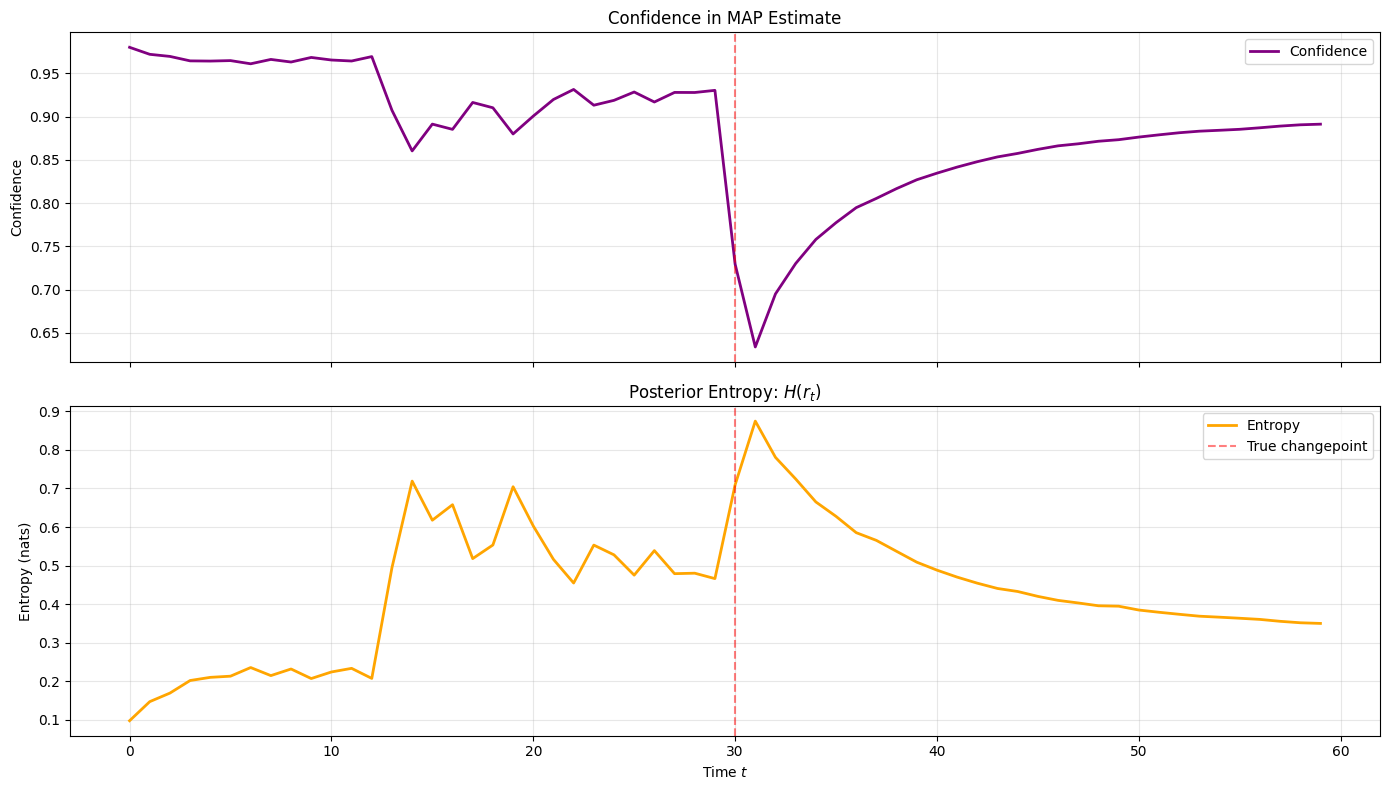

Note: High entropy = high uncertainty, inverse relationship with confidence


In [8]:
def compute_entropy(posterior):
    """Compute Shannon entropy of posterior distribution"""
    # Avoid log(0)
    p_nonzero = posterior[posterior > 1e-10]
    return -np.sum(p_nonzero * np.log(p_nonzero))

# Compute entropy at each time
entropy = np.array([compute_entropy(p) for p in posteriors])

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Confidence
ax1.plot(confidence, linewidth=2, color='purple', label='Confidence')
ax1.axvline(30, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Confidence')
ax1.set_title('Confidence in MAP Estimate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Entropy
ax2.plot(entropy, linewidth=2, color='orange', label='Entropy')
ax2.axvline(30, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel('Entropy (nats)')
ax2.set_title('Posterior Entropy: $H(r_t)$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: High entropy = high uncertainty, inverse relationship with confidence")

---
## 9. Practical Example: Multiple Changepoints

Let's apply all these concepts to a more complex scenario with multiple changepoints.

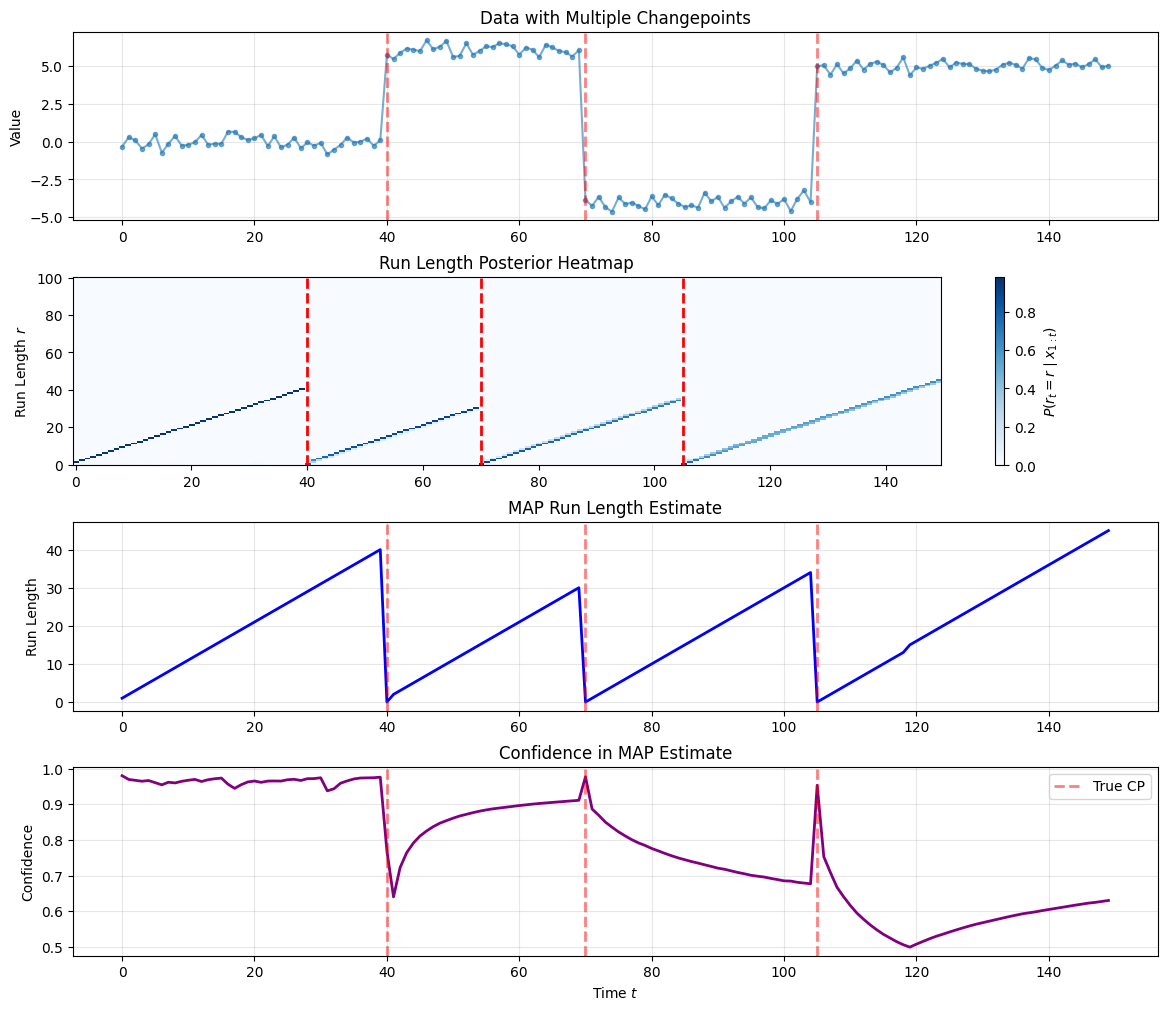

In [9]:
# Generate data with 3 changepoints - dramatic shifts, low noise
np.random.seed(123)
data_complex = np.concatenate([
    np.random.randn(40) * 0.3 + 0.0,    # Segment 1: mean=0
    np.random.randn(30) * 0.3 + 6.0,    # Segment 2: mean=6
    np.random.randn(35) * 0.3 + -4.0,   # Segment 3: mean=-4
    np.random.randn(45) * 0.3 + 5.0     # Segment 4: mean=5
])

true_cps = [40, 70, 105]

# Run BOCPD
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)
bocpd = BOCPD(model, hazard, max_run_length=100)

posteriors_complex = []
for x in data_complex:
    posterior_r, _ = bocpd.update(x)
    posteriors_complex.append(posterior_r.copy())

posteriors_complex = np.array(posteriors_complex)
map_complex = np.argmax(posteriors_complex, axis=1)
confidence_complex = posteriors_complex[np.arange(len(posteriors_complex)), map_complex]

# Comprehensive visualization
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(4, 1, hspace=0.3)

# Data
ax1 = fig.add_subplot(gs[0])
ax1.plot(data_complex, 'o-', alpha=0.6, markersize=3)
for cp in true_cps:
    ax1.axvline(cp, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax1.set_ylabel('Value')
ax1.set_title('Data with Multiple Changepoints')
ax1.grid(True, alpha=0.3)

# Posterior heatmap
ax2 = fig.add_subplot(gs[1])
im = ax2.imshow(posteriors_complex.T, aspect='auto', origin='lower', 
                cmap='Blues', interpolation='nearest')
for cp in true_cps:
    ax2.axvline(cp, color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Run Length $r$')
ax2.set_title('Run Length Posterior Heatmap')
plt.colorbar(im, ax=ax2, label='$P(r_t = r \\mid x_{1:t})$')

# MAP estimate
ax3 = fig.add_subplot(gs[2])
ax3.plot(map_complex, linewidth=2, color='blue')
for cp in true_cps:
    ax3.axvline(cp, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax3.set_ylabel('Run Length')
ax3.set_title('MAP Run Length Estimate')
ax3.grid(True, alpha=0.3)

# Confidence
ax4 = fig.add_subplot(gs[3])
ax4.plot(confidence_complex, linewidth=2, color='purple')
for cp in true_cps:
    ax4.axvline(cp, color='red', linestyle='--', alpha=0.5, linewidth=2, label='True CP' if cp == true_cps[0] else '')
ax4.set_xlabel('Time $t$')
ax4.set_ylabel('Confidence')
ax4.set_title('Confidence in MAP Estimate')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.show()

---
## Summary

### BOCPD Outputs Explained

1. **Posterior Distribution** $P(r_t = r \mid x_{1:t})$
   - Complete probabilistic information about run length
   - Sums to 1 (valid probability distribution)
   - Visualize as heatmap to see segmentation structure

2. **Changepoint Probability** $P(r_t = 0 \mid x_{1:t})$
   - First element of posterior distribution
   - High value indicates likely changepoint
   - Commonly used with threshold-based detection

3. **MAP Estimate** $r_{MAP}(t) = \arg\max_r P(r_t = r \mid x_{1:t})$
   - Most probable run length (mode of distribution)
   - Provides point estimate for decision-making
   - Preferred for changepoint detection: $r_{MAP} = 0$ means CP is most likely

4. **Confidence** $P(r_t = r_{MAP} \mid x_{1:t})$
   - Probability mass at MAP estimate
   - Quantifies certainty in the estimate
   - Essential for filtering low-confidence detections

5. **Uncertainty Quantification**
   - Credible intervals: Range containing X% of posterior mass
   - Entropy: Overall distribution spread
   - Critical for robust decision-making

### Best Practices

- **Use full posterior** when you need complete probabilistic information
- **Use CP probability** for simple threshold-based detection
- **Use MAP + confidence** for robust changepoint detection (recommended)
- **Visualize posterior heatmap** to understand algorithm behavior
- **Check confidence** before acting on detections

### Next Steps

- **04_parameter_guide.ipynb:** Learn how hyperparameters affect these outputs
- **05_advanced_features.ipynb:** Production-ready changepoint detection
- **06_real_world_us30_volatility.ipynb:** Apply to real financial data